# Тюнинг линейной регрессии и ошибки

### О задании

В этом задании вы:
- обучите линейную регрессию, познакомитесь с метриками качества в задачах регресии

In [ ]:
%pylab inline
import pandas as pd

from sklearn.base import BaseEstimator
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

Populating the interactive namespace from numpy and matplotlib


## Часть 1. Линейная регрессия

Для начала загрузим данные и разделим их на обучающую и тестовую выборки в соотношении 7 к 3. Зачем так делать? Когда вы проверяете себя на данных на которых не обучались, вы можете быть уверены что не переобучились. Таким образом если качество на 70% датасета (оубчающей выборке) растёт, а на тестовой выборке падает, то модель начала запоминать датасет (переобучилась), вы что-то делаете не так.


In [ ]:
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, train_size=0.7, random_state=241)

__Задание 1.__ Обучение линейной регрессии.

**(4 балла)**

Обучите линейную регрессию с $L_1$ (Lasso) и $L_2$ (Ridge) регуляризаторами (используйте параметры по умолчанию). Посмотрите, какое количество коэффициентов близко к 0 (степень близости к 0 определите сами из разумных пределов). Постройте график зависимости числа ненулевых коэффициентов от коэффицента регуляризации (перебирайте значения по логарифмической сетке от $10^{-3}$ до $10^3$).

Спойлер - при большом гиперпараметре регуляризации все параметры стремятся к нулю. На графике это должно быть видно.

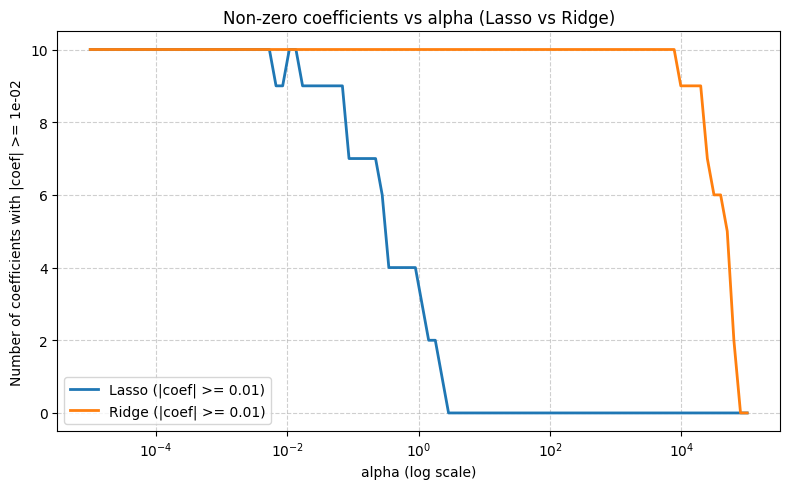

=== Ridge default (alpha=1.0) on TEST ===
RMSE = 58.3043
MAE  = 49.6028
R^2  = 0.3599

Best alphas on TRAIN set:
  best_alpha (train RMSE) = 1e-05
  best_alpha (train MAE)  = 0.001047615752789665
  best_alpha (train R2)   = 1e-05



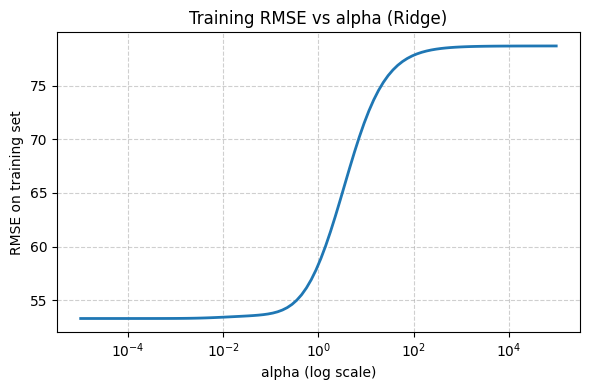

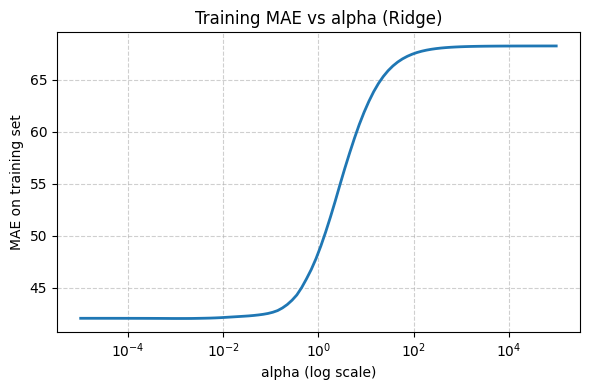

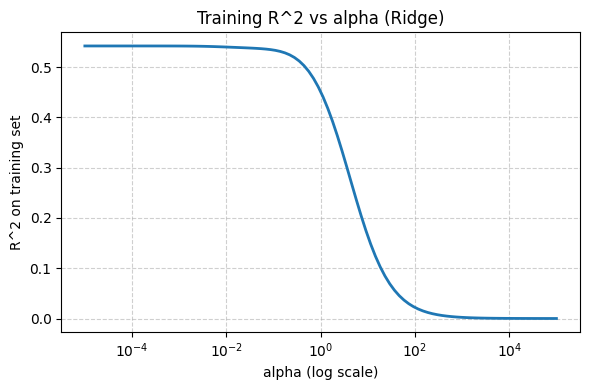

=== Ridge on TEST: default vs tuned (alphas chosen on TRAIN) ===
   alpha      RMSE       MAE       R2
1.000000 58.304295 49.602751 0.359902
0.000010 55.918263 47.198094 0.411220
0.001048 55.855383 47.153707 0.412544
0.000010 55.918263 47.198094 0.411220
Best alphas on TEST set:
  best_alpha (test RMSE) = 0.08697490026177834
  best_alpha (test MAE)  = 0.021544346900318846
  best_alpha (test R2)   = 0.08697490026177834



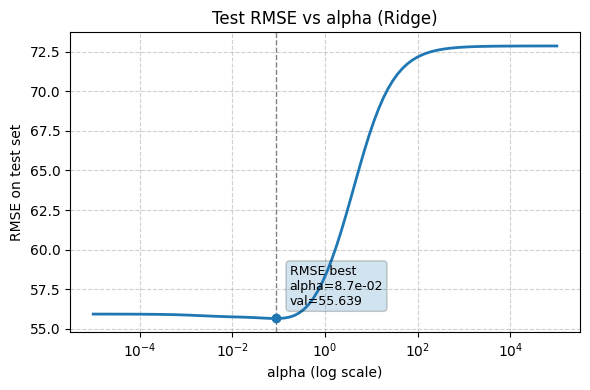

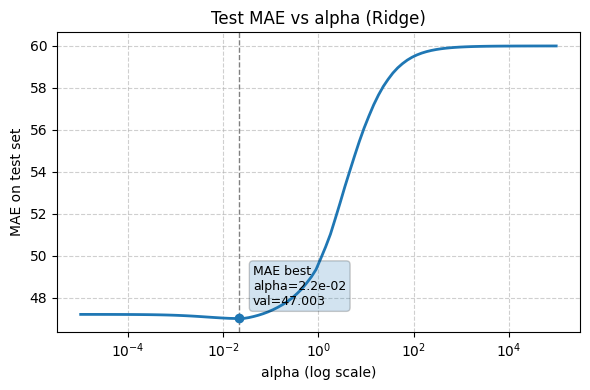

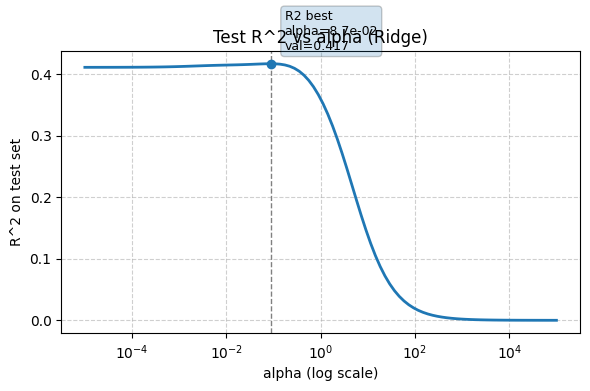

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import warnings


# --------------- Параметры ---------------
RANDOM_STATE = 241
TRAIN_SIZE = 0.7
ALPHA_GRID = np.logspace(-5, 5, 100)
NEAR_ZERO_THRESH = 1e-2
LASSO_MAX_ITER = 10000

# --------------- Загрузка и разбиение ---------------
data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE
)

# --------------- Обучение моделей по умолчанию ---------------
lasso_default = Lasso(max_iter=LASSO_MAX_ITER)
ridge_default = Ridge()

lasso_default.fit(X_train, y_train)
ridge_default.fit(X_train, y_train)

coef_lasso = lasso_default.coef_
coef_ridge = ridge_default.coef_


# --------------- Sweep alpha: число "ненулевых" коэффициентов ---------------
nnz_lasso = []
nnz_ridge = []

for a in ALPHA_GRID:
    l = Lasso(alpha=a, max_iter=LASSO_MAX_ITER)
    l.fit(X_train, y_train)
    nnz_lasso.append(int(np.sum(np.abs(l.coef_) >= NEAR_ZERO_THRESH)))

    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    nnz_ridge.append(int(np.sum(np.abs(r.coef_) >= NEAR_ZERO_THRESH)))

# График числа ненулевых коэффициентов vs alpha (log-scale)
plt.figure(figsize=(8,5))
plt.semilogx(ALPHA_GRID, nnz_lasso, label=f'Lasso (|coef| >= {NEAR_ZERO_THRESH})', linewidth=2)
plt.semilogx(ALPHA_GRID, nnz_ridge, label=f'Ridge (|coef| >= {NEAR_ZERO_THRESH})', linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('Number of coefficients with |coef| >= {:.0e}'.format(NEAR_ZERO_THRESH))
plt.title('Non-zero coefficients vs alpha (Lasso vs Ridge)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --------------- Ridge: метрики на тесте для default (alpha=1.0) ---------------
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

y_pred_default = ridge_default.predict(X_test)
rmse_default = rmse(y_test, y_pred_default)
mae_default = mean_absolute_error(y_test, y_pred_default)
r2_default = r2_score(y_test, y_pred_default)

print("=== Ridge default (alpha=1.0) on TEST ===")
print(f"RMSE = {rmse_default:.4f}")
print(f"MAE  = {mae_default:.4f}")
print(f"R^2  = {r2_default:.4f}\n")

# --------------- Подбор alpha на обучающей выборке (по метрикам) ---------------
train_rmse = []
train_mae = []
train_r2 = []

for a in ALPHA_GRID:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    yp = r.predict(X_train)
    train_rmse.append(rmse(y_train, yp))
    train_mae.append(mean_absolute_error(y_train, yp))
    train_r2.append(r2_score(y_train, yp))

train_rmse = np.array(train_rmse)
train_mae = np.array(train_mae)
train_r2 = np.array(train_r2)

best_alpha_rmse = float(ALPHA_GRID[np.argmin(train_rmse)])
best_alpha_mae = float(ALPHA_GRID[np.argmin(train_mae)])
best_alpha_r2 = float(ALPHA_GRID[np.argmax(train_r2)])

print("Best alphas on TRAIN set:")
print(f"  best_alpha (train RMSE) = {best_alpha_rmse}")
print(f"  best_alpha (train MAE)  = {best_alpha_mae}")
print(f"  best_alpha (train R2)   = {best_alpha_r2}\n")

# --------------- Графики зависимостей метрик на train от alpha ---------------
plt.figure(figsize=(6,4))
plt.semilogx(ALPHA_GRID, train_rmse, linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('RMSE on training set')
plt.title('Training RMSE vs alpha (Ridge)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.semilogx(ALPHA_GRID, train_mae, linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('MAE on training set')
plt.title('Training MAE vs alpha (Ridge)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.semilogx(ALPHA_GRID, train_r2, linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('R^2 on training set')
plt.title('Training R^2 vs alpha (Ridge)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --------------- Оценка на тесте моделей с выбранными alpha ---------------
def eval_ridge(alpha, X_tr, y_tr, X_te, y_te):
    model = Ridge(alpha=alpha)
    model.fit(X_tr, y_tr)
    ypred = model.predict(X_te)
    return {
        'alpha': alpha,
        'RMSE': rmse(y_te, ypred),
        'MAE': mean_absolute_error(y_te, ypred),
        'R2': r2_score(y_te, ypred)
    }

results = []
results.append(eval_ridge(1.0, X_train, y_train, X_test, y_test))  # default
results.append(eval_ridge(best_alpha_rmse, X_train, y_train, X_test, y_test))
results.append(eval_ridge(best_alpha_mae, X_train, y_train, X_test, y_test))
results.append(eval_ridge(best_alpha_r2, X_train, y_train, X_test, y_test))

df_results = pd.DataFrame(results)
print("=== Ridge on TEST: default vs tuned (alphas chosen on TRAIN) ===")
print(df_results.to_string(index=False))

# ------------------------------

test_rmse = []
test_mae = []
test_r2 = []

for a in ALPHA_GRID:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    yp_test = r.predict(X_test)
    test_rmse.append(rmse(y_test, yp_test))
    test_mae.append(mean_absolute_error(y_test, yp_test))
    test_r2.append(r2_score(y_test, yp_test))

test_rmse = np.array(test_rmse)
test_mae = np.array(test_mae)
test_r2 = np.array(test_r2)

# лучшие alpha на тесте
best_test_alpha_rmse = float(ALPHA_GRID[np.argmin(test_rmse)])
best_test_alpha_mae  = float(ALPHA_GRID[np.argmin(test_mae)])
best_test_alpha_r2   = float(ALPHA_GRID[np.argmax(test_r2)])

print("Best alphas on TEST set:")
print(f"  best_alpha (test RMSE) = {best_test_alpha_rmse}")
print(f"  best_alpha (test MAE)  = {best_test_alpha_mae}")
print(f"  best_alpha (test R2)   = {best_test_alpha_r2}\n")

# --- функция для удобной разметки лучшей точки на графике ---
def mark_best(alpha_grid, metric_vals, best_alpha, label_text):
    best_idx = np.argmin(metric_vals) if label_text != 'R2' else np.argmax(metric_vals)
    best_a = alpha_grid[best_idx]
    best_v = metric_vals[best_idx]
    plt.axvline(best_a, color='gray', linestyle='--', linewidth=1)
    plt.scatter([best_a], [best_v], zorder=5)
    plt.annotate(f"{label_text} best\nalpha={best_a:.1e}\nval={best_v:.3f}",
                 xy=(best_a, best_v), xytext=(10, 10),
                 textcoords='offset points', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

# График RMSE на тесте
plt.figure(figsize=(6,4))
plt.semilogx(ALPHA_GRID, test_rmse, linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('RMSE on test set')
plt.title('Test RMSE vs alpha (Ridge)')
plt.grid(True, which="both", ls="--", alpha=0.6)
mark_best(ALPHA_GRID, test_rmse, best_test_alpha_rmse, 'RMSE')
plt.tight_layout()
plt.show()

# График MAE на тесте
plt.figure(figsize=(6,4))
plt.semilogx(ALPHA_GRID, test_mae, linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('MAE on test set')
plt.title('Test MAE vs alpha (Ridge)')
plt.grid(True, which="both", ls="--", alpha=0.6)
mark_best(ALPHA_GRID, test_mae, best_test_alpha_mae, 'MAE')
plt.tight_layout()
plt.show()

# График R^2 на тесте
plt.figure(figsize=(6,4))
plt.semilogx(ALPHA_GRID, test_r2, linewidth=2)
plt.xlabel('alpha (log scale)')
plt.ylabel('R^2 on test set')
plt.title('Test R^2 vs alpha (Ridge)')
plt.grid(True, which="both", ls="--", alpha=0.6)
# для R2 наилучшее значение — максимум
best_idx_r2 = np.argmax(test_r2)
best_a_r2 = ALPHA_GRID[best_idx_r2]
best_v_r2 = test_r2[best_idx_r2]
plt.axvline(best_a_r2, color='gray', linestyle='--', linewidth=1)
plt.scatter([best_a_r2], [best_v_r2], zorder=5)
plt.annotate(f"R2 best\nalpha={best_a_r2:.1e}\nval={best_v_r2:.3f}",
             xy=(best_a_r2, best_v_r2), xytext=(10, 10),
             textcoords='offset points', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
plt.tight_layout()
plt.show()


Посчитайте для Ridge-регрессии следующие метрики: $RMSE$, $MAE$, $R^2$.

Подберите на обучающей выборке для Ridge-регрессии коэффициент регуляризации (перебирайте значения по логарифмической сетке от $10^{-3}$ до $10^3$) для каждой из метрик. Постройте графики зависимости фукнции потерь от коэффициента регуляризации. Посчитайте те же метрики снова. Заметно ли изменилось качество?

__Задание 2.__ Поиск объектов-выбросов

**(4 балла)**

Как известно, MSE сильно штрафует за большие ошибки на объектах-выбросах. Посчитайте ошибки и посмотрите на их распределение (plt.hist). Что вы видите?

Попробуйте удалить объекты-выбросы из обучающей выборки (что считать или не считать выбросами на ваше усмотрение). Обучите модель заново и посмотрите на качество на отложенной выборке (учитывайте, что там тоже могут быть выбросы, с которыми вы ничего не можете сделать). Стало ли лучше? Чем вы можете объяснить это?

In [ ]:
# code here

__Задание 3.__ Отчёт

**(2 балла)**

In [ ]:
# code here